# EDA and Hypothesis Testing
## Weather and Goal Scoring in Beşiktaş Home Matches

This notebook only examines the relationship between **rainy weather** and **total goals** in Beşiktaş home matches.

Only **one hypothesis test** is used:
- **Two-sample t-test**

This matches the course material on comparing the means of two independent groups.


In [ ]:
# Goal:
# Compare total goals in rainy vs non-rainy Beşiktaş home matches.
#
# Hypotheses:
# H0: The mean total goals are the same in rainy and non-rainy matches.
# H1: The mean total goals are different in rainy and non-rainy matches.



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [ ]:
#read data
df = pd.read_csv("clean_data.csv")
df.head()

,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,HF,AF,HY,AY,HR,AR,season_code,kickoff_local,besiktas_goals,opponent_goals,total_goals,kickoff_hour,time,temperature_2m,precipitation,rain,wind_speed_10m,rainy_match,heavy_rain_match
0,2015-08-22,19:00,Besiktas,Trabzonspor,1.0,2.0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1516,2015-08-22 19:00:00,1.0,2.0,3.0,2015-08-22 19:00:00,2015-08-22 19:00:00,25.0,0.0,0.0,30.2,0,0
1,2015-09-13,19:00,Besiktas,Buyuksehyr,2.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1516,2015-09-13 19:00:00,2.0,0.0,2.0,2015-09-13 19:00:00,2015-09-13 19:00:00,22.0,0.0,0.0,24.7,0,0
2,2015-09-27,19:00,Besiktas,Fenerbahce,3.0,2.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1516,2015-09-27 19:00:00,3.0,2.0,5.0,2015-09-27 19:00:00,2015-09-27 19:00:00,24.6,0.0,0.0,17.7,0,0
3,2015-10-18,19:00,Besiktas,Rizespor,1.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1516,2015-10-18 19:00:00,1.0,0.0,1.0,2015-10-18 19:00:00,2015-10-18 19:00:00,17.5,0.0,0.0,12.5,0,0
4,2015-10-30,19:00,Besiktas,Kasimpasa,3.0,3.0,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1516,2015-10-30 19:00:00,3.0,3.0,6.0,2015-10-30 19:00:00,2015-10-30 19:00:00,13.2,0.0,0.0,31.3,0,0


## Dataset overview


In [7]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (179, 30)

Columns:
['Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'season_code', 'kickoff_local', 'besiktas_goals', 'opponent_goals', 'total_goals', 'kickoff_hour', 'time', 'temperature_2m', 'precipitation', 'rain', 'wind_speed_10m', 'rainy_match', 'heavy_rain_match']


In [8]:
# We only need these columns for this notebook
analysis_df = df[["Date", "AwayTeam", "total_goals", "rainy_match"]].copy()
analysis_df.head()


,Date,AwayTeam,total_goals,rainy_match
0,2015-08-22,Trabzonspor,3.0,0
1,2015-09-13,Buyuksehyr,2.0,0
2,2015-09-27,Fenerbahce,5.0,0
3,2015-10-18,Rizespor,1.0,0
4,2015-10-30,Kasimpasa,6.0,0


In [9]:
analysis_df.describe(include="all")


,Date,AwayTeam,total_goals,rainy_match
count,179,179,179.000000,179.000000
unique,179,37,NaN,NaN
top,2015-08-22,Trabzonspor,NaN,NaN
freq,1,10,NaN,NaN
mean,NaN,NaN,3.072626,0.145251
std,NaN,NaN,1.572331,0.353342
min,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,2.000000,0.000000
50%,NaN,NaN,3.000000,0.000000
75%,NaN,NaN,4.000000,0.000000


In [10]:
analysis_df["rainy_match"].value_counts()


,count
rainy_match,
0,153
1,26


## Exploratory Data Analysis


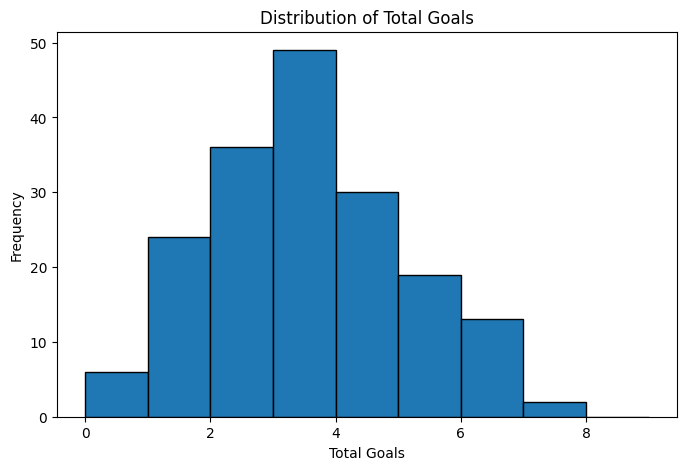

In [11]:
# Total goals distribution
plt.figure(figsize=(8,5))
plt.hist(analysis_df["total_goals"].dropna(), bins=range(0,10), edgecolor="black")
plt.title("Distribution of Total Goals")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.show()


In [12]:
# Separate rainy and non-rainy matches
rainy_goals = analysis_df.loc[analysis_df["rainy_match"] == 1, "total_goals"].dropna()
non_rainy_goals = analysis_df.loc[analysis_df["rainy_match"] == 0, "total_goals"].dropna()

print("Rainy matches:", len(rainy_goals))
print("Non-rainy matches:", len(non_rainy_goals))
print("Mean total goals in rainy matches:", rainy_goals.mean())
print("Mean total goals in non-rainy matches:", non_rainy_goals.mean())
print("Std. dev. in rainy matches:", rainy_goals.std())
print("Std. dev. in non-rainy matches:", non_rainy_goals.std())


Rainy matches: 26
Non-rainy matches: 153
Mean total goals in rainy matches: 3.5384615384615383
Mean total goals in non-rainy matches: 2.9934640522875817
Std. dev. in rainy matches: 1.4486067577025654
Std. dev. in non-rainy matches: 1.5832043291099294


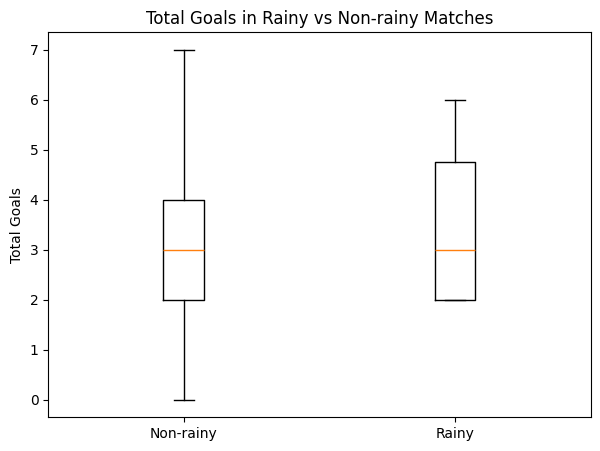

In [13]:
# Visual comparison
plt.figure(figsize=(7,5))
plt.boxplot([non_rainy_goals, rainy_goals], tick_labels=["Non-rainy", "Rainy"])
plt.title("Total Goals in Rainy vs Non-rainy Matches")
plt.ylabel("Total Goals")
plt.show()


## Hypothesis test: Two-sample t-test


In [14]:
# Two-sample t-test
# We use a two-sided test because the question is whether rain affects goals,
# not specifically whether it increases or decreases them.

t_stat, p_value = ttest_ind(rainy_goals, non_rainy_goals, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: 1.7490463894779207
p-value: 0.08882082544824235


In [15]:
# Decision at alpha = 0.05
alpha = 0.05

if p_value < alpha:
    print("Reject H0: there is a statistically significant difference in mean total goals.")
else:
    print("Fail to reject H0: there is not enough evidence of a significant difference in mean total goals.")


Fail to reject H0: there is not enough evidence of a significant difference in mean total goals.


## Conclusion


- Number of rainy matches: 26
- Number of non-rainy matches: 153
- Mean goals in rainy matches: 3.538462
- Mean goals in non-rainy matches: 2.993464
- p-value: 0.08882082544824235

Based on the two-sample t-test, there is not enough statistical evidence to conclude that rainy weather affects the mean total number of goals in Beşiktaş home matches.
There were 26 rainy matches and 153 non-rainy matches in the dataset. The mean total goals was 3.54 in rainy matches and 2.99 in non-rainy matches. However, the p-value was 0.0888, which is greater than the significance level of 0.05. Therefore, the null hypothesis cannot be rejected.


In [16]:
#Summary table
summary = pd.DataFrame({
    "Metric": [
        "Rainy matches",
        "Non-rainy matches",
        "Mean goals (rainy)",
        "Mean goals (non-rainy)",
        "t-statistic",
        "p-value"
    ],
    "Value": [
        len(rainy_goals),
        len(non_rainy_goals),
        rainy_goals.mean(),
        non_rainy_goals.mean(),
        t_stat,
        p_value
    ]
})

summary


,Metric,Value
0,Rainy matches,26.000000
1,Non-rainy matches,153.000000
2,Mean goals (rainy),3.538462
3,Mean goals (non-rainy),2.993464
4,t-statistic,1.749046
5,p-value,0.088821
